In [1]:
# Imports
import time, json, glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow : 2.19.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Paths
DRIVE_BASE    = '/content/drive/MyDrive/ids-project/workspace'

SPLIT_DIR     = f'{DRIVE_BASE}/dataset/splits_stratified'
LABEL_MAP_DIR = f'{DRIVE_BASE}/dataset/label_mapping'
RF_IMPORT_DIR = f'{DRIVE_BASE}/dataset/rf_feature_importance'
OUTPUT_DIR    = f'{DRIVE_BASE}/output'
MODEL_DIR     = f'{DRIVE_BASE}/models'

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODEL_DIR,  exist_ok=True)

LABEL_COL    = 'label_idx'
TOP_K        = 30
RANDOM_STATE = 42

In [5]:
# Load label mapping
label_map_files = glob.glob(f'{LABEL_MAP_DIR}/*.csv')

print(f"Searching for label mapping files in: {LABEL_MAP_DIR}")
print(f"Files found: {label_map_files}")

if not label_map_files:
    print("Error: No label mapping CSV files found. Please ensure they are in the correct directory.")
else:
    # Read CSVs, assuming they have a header row and using it for column names
    label_map_df = pd.concat([pd.read_csv(f, header=0, names=['label_idx','label_name'])
                              for f in label_map_files], ignore_index=True)
    label_map_df['label_idx'] = label_map_df['label_idx'].astype(int)
    label_map_df = label_map_df.sort_values('label_idx').reset_index(drop=True)

    ATTACK_NAMES = dict(zip(label_map_df['label_idx'], label_map_df['label_name']))
    N_CLASSES    = len(ATTACK_NAMES)
    TARGET_NAMES = [ATTACK_NAMES[i] for i in range(N_CLASSES)]

    print(f'Loaded label mapping: {N_CLASSES} classes')
    print(list(ATTACK_NAMES.items()))

Searching for label mapping files in: /content/drive/MyDrive/ids-project/workspace/dataset/label_mapping
Files found: ['/content/drive/MyDrive/ids-project/workspace/dataset/label_mapping/part-00000-41fa5cd0-f21b-46e5-8f36-9f7ef6e5b32a-c000.csv']
Loaded label mapping: 15 classes
[(0, 'Benign'), (1, 'DDOS attack-HOIC'), (2, 'DDoS attacks-LOIC-HTTP'), (3, 'DoS attacks-Hulk'), (4, 'Bot'), (5, 'FTP-BruteForce'), (6, 'SSH-Bruteforce'), (7, 'Infilteration'), (8, 'DoS attacks-SlowHTTPTest'), (9, 'DoS attacks-GoldenEye'), (10, 'DoS attacks-Slowloris'), (11, 'DDOS attack-LOIC-UDP'), (12, 'Brute Force -Web'), (13, 'Brute Force -XSS'), (14, 'SQL Injection')]


In [6]:
# Load top-K features from RF importance artifact
rf_files = glob.glob(f'{RF_IMPORT_DIR}/*.csv')
rf_df = pd.concat([pd.read_csv(f) for f in rf_files], ignore_index=True)
rf_df.columns = ['feature', 'importance']
rf_df['importance'] = rf_df['importance'].astype(float)
rf_df = rf_df.sort_values('importance', ascending=False)

FEATURE_COLS_RAW = rf_df['feature'].head(TOP_K).tolist()

print(f'Top-{TOP_K} features from RF artifact:')
print(FEATURE_COLS_RAW)

Top-30 features from RF artifact:
['Init Fwd Win Byts', 'Dst Port', 'Fwd Seg Size Min', 'timestamp_unix', 'Fwd Pkt Len Max', 'Fwd Header Len', 'Subflow Fwd Byts', 'TotLen Fwd Pkts', 'Flow Duration', 'Flow IAT Max', 'Fwd IAT Min', 'Flow IAT Min', 'Fwd Pkts/s', 'Fwd Seg Size Avg', 'Flow Pkts/s', 'Flow IAT Mean', 'Fwd IAT Max', 'Fwd Pkt Len Mean', 'Init Bwd Win Byts', 'Fwd IAT Mean', 'Fwd IAT Tot', 'Fwd Pkt Len Std', 'Bwd Pkt Len Mean', 'Pkt Len Std', 'Bwd Pkts/s', 'Bwd Seg Size Avg', 'Bwd Pkt Len Std', 'Tot Fwd Pkts', 'Pkt Size Avg', 'Subflow Fwd Pkts']


In [7]:
# Load splits into numpy arrays
import gc

def load_split_numpy(split_name, feature_cols_raw, label_col):
    files = sorted(
        glob.glob(f'{SPLIT_DIR}/{split_name}/**/*.parquet', recursive=True) +
        glob.glob(f'{SPLIT_DIR}/{split_name}/*.parquet')
    )
    X_parts, y_parts, all_cols = [], [], None
    for f in files:
        df = pd.read_parquet(f)
        # Remove timestamp
        if all_cols is None:
            all_cols = set(df.columns)
        X_parts.append(df[[c for c in feature_cols_raw if c in all_cols and c != 'timestamp_unix']].values.astype(np.float32))
        y_parts.append(df[label_col].values.astype(np.int32))
        del df
        gc.collect()
    X = np.concatenate(X_parts)
    y = np.concatenate(y_parts)
    del X_parts, y_parts
    gc.collect()
    return X, y, [c for c in feature_cols_raw if c in all_cols and c != 'timestamp_unix']

print('Loading train...')
X_train, y_train, FEATURE_COLS = load_split_numpy('train', FEATURE_COLS_RAW, LABEL_COL)
print(f'  X_train: {X_train.shape}  {X_train.nbytes/1e6:.0f} MB')

print('Loading val...')
X_val, y_val, _ = load_split_numpy('val', FEATURE_COLS_RAW, LABEL_COL)
print(f'  X_val: {X_val.shape}  {X_val.nbytes/1e6:.0f} MB')

print('Loading test...')
X_test, y_test, _ = load_split_numpy('test', FEATURE_COLS_RAW, LABEL_COL)
print(f'  X_test: {X_test.shape}  {X_test.nbytes/1e6:.0f} MB')

N_FEATURES = X_train.shape[1]
n_train, n_val, n_test = len(y_train), len(y_val), len(y_test)
n_total = n_train + n_val + n_test

print(f'\nUsing {len(FEATURE_COLS)} features (timestamp_unix excluded)')
print(f'Train  : {n_train:>10,}  ({n_train/n_total*100:.1f}%)')
print(f'Val    : {n_val:>10,}  ({n_val/n_total*100:.1f}%)')
print(f'Test   : {n_test:>10,}  ({n_test/n_total*100:.1f}%)')
print(f'Total  : {n_total:>10,}')

Loading train...
  X_train: (8052574, 29)  934 MB
Loading val...
  X_val: (1722968, 29)  200 MB
Loading test...
  X_test: (1727194, 29)  200 MB

Using 29 features (timestamp_unix excluded)
Train  :  8,052,574  (70.0%)
Val    :  1,722,968  (15.0%)
Test   :  1,727,194  (15.0%)
Total  : 11,502,736


,label_idx,count,label_name,pct
0,0,4203558,Benign,52.201
1,1,960974,DDOS attack-HOIC,11.934
2,2,807424,DDoS attacks-LOIC-HTTP,10.027
3,3,647090,DoS attacks-Hulk,8.036
4,4,400962,Bot,4.979
5,5,270616,FTP-BruteForce,3.361
6,6,262550,SSH-Bruteforce,3.260
7,7,225990,Infilteration,2.806
8,8,196076,DoS attacks-SlowHTTPTest,2.435
9,9,58348,DoS attacks-GoldenEye,0.725


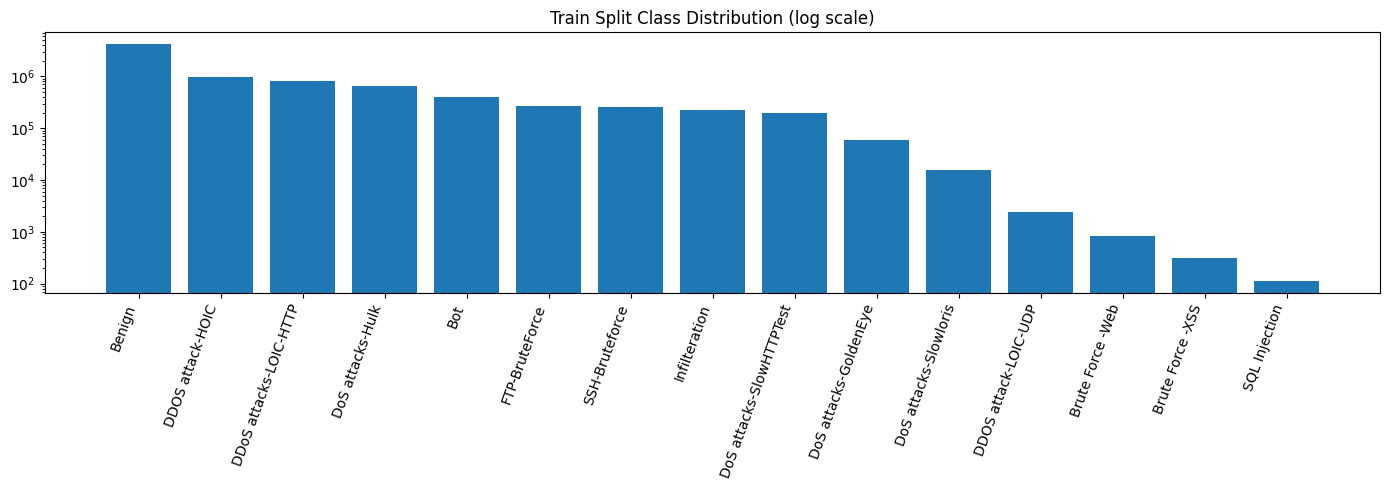

In [8]:
# Class distribution
from collections import Counter

dist = pd.DataFrame(
    [(k, v, ATTACK_NAMES[k]) for k, v in sorted(Counter(y_train).items())],
    columns=[LABEL_COL, 'count', 'label_name']
)
dist['pct'] = (dist['count'] / dist['count'].sum() * 100).round(3)
display(dist)

plt.figure(figsize=(14, 5))
plt.bar(dist['label_name'], dist['count'])
plt.xticks(rotation=70, ha='right')
plt.yscale('log')
plt.title('Train Split Class Distribution (log scale)')
plt.tight_layout()
plt.show()

In [9]:
# Oversample tiny classes
MIN_SAMPLES  = 5000

counts = dict(Counter(y_train))
tiny_classes = [c for c, cnt in counts.items() if cnt < MIN_SAMPLES]
print(f'Oversampling {len(tiny_classes)} tiny classes to {MIN_SAMPLES} min samples:')
print(f'  {[ATTACK_NAMES[c] for c in tiny_classes]}')

if tiny_classes:
    X_parts = [X_train]
    y_parts = [y_train]

    for c in tiny_classes:
        idx = np.where(y_train == c)[0]
        n_needed = MIN_SAMPLES - len(idx)
        # Sample with replacement to reach MIN_SAMPLES
        extra_idx = np.random.choice(idx, size=n_needed, replace=True)
        X_parts.append(X_train[extra_idx])
        y_parts.append(y_train[extra_idx])
        print(f'  {ATTACK_NAMES[c]:30s}  {len(idx):>6,} → {len(idx)+n_needed:>6,}')

    X_train = np.concatenate(X_parts)
    y_train = np.concatenate(y_parts)
    del X_parts, y_parts
    gc.collect()

    # Shuffle so oversampled rows aren't all at the end
    shuffle_idx = np.random.permutation(len(X_train))
    X_train = X_train[shuffle_idx]
    y_train = y_train[shuffle_idx]

    n_train = len(y_train)
    print(f'\nTrain size after oversampling: {n_train:,}')

Oversampling 4 tiny classes to 5000 min samples:
  ['DDOS attack-LOIC-UDP', 'Brute Force -Web', 'Brute Force -XSS', 'SQL Injection']
  DDOS attack-LOIC-UDP             2,378 →  5,000
  Brute Force -Web                   850 →  5,000
  Brute Force -XSS                   312 →  5,000
  SQL Injection                      112 →  5,000

Train size after oversampling: 8,068,922


In [10]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Reshape for LSTM: (samples, timesteps, features) = (n, N_FEATURES, 1)
# Each feature is one timestep
X_train_lstm = X_train_scaled.reshape(-1, N_FEATURES, 1)
X_val_lstm   = X_val_scaled.reshape(-1, N_FEATURES, 1)
X_test_lstm  = X_test_scaled.reshape(-1, N_FEATURES, 1)

y_train_oh = tf.keras.utils.to_categorical(y_train, N_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   N_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  N_CLASSES)

print(f'X_train_lstm : {X_train_lstm.shape}')
print(f'y_train_oh   : {y_train_oh.shape}')

joblib.dump(scaler, f'{MODEL_DIR}/lstm_scaler.pkl')
print(f'Scaler saved: {MODEL_DIR}/lstm_scaler.pkl')

X_train_lstm : (8068922, 29, 1)
y_train_oh   : (8068922, 15)
Scaler saved: /content/drive/MyDrive/ids-project/workspace/models/lstm_scaler.pkl


In [11]:
# Inverse-frequency class weights
from collections import Counter

class_counts = dict(Counter(y_train))
n_classes    = len(ATTACK_NAMES)
MAX_WEIGHT   = 15.0

raw_weights = {
    c: n_train / (n_classes * cnt)
    for c, cnt in class_counts.items()
}
class_weights = {
    c: min(w, MAX_WEIGHT)
    for c, w in raw_weights.items()
}

BENIGN_CLASS = [c for c, name in ATTACK_NAMES.items() if 'benign' in name.lower()][0]
class_weights[BENIGN_CLASS] = max(class_weights[BENIGN_CLASS], 0.4)

print('Class weights (inverse frequency, capped at 15):')
for c in sorted(class_weights):
    print(f'  {ATTACK_NAMES[c]:30s}  count={class_counts.get(c,0):>9,}  weight={class_weights[c]:.4f}')

Class weights (inverse frequency, capped at 15):
  Benign                          count=4,203,558  weight=0.4000
  DDOS attack-HOIC                count=  960,974  weight=0.5598
  DDoS attacks-LOIC-HTTP          count=  807,424  weight=0.6662
  DoS attacks-Hulk                count=  647,090  weight=0.8313
  Bot                             count=  400,962  weight=1.3416
  FTP-BruteForce                  count=  270,616  weight=1.9878
  SSH-Bruteforce                  count=  262,550  weight=2.0489
  Infilteration                   count=  225,990  weight=2.3803
  DoS attacks-SlowHTTPTest        count=  196,076  weight=2.7435
  DoS attacks-GoldenEye           count=   58,348  weight=9.2193
  DoS attacks-Slowloris           count=   15,334  weight=15.0000
  DDOS attack-LOIC-UDP            count=    5,000  weight=15.0000
  Brute Force -Web                count=    5,000  weight=15.0000
  Brute Force -XSS                count=    5,000  weight=15.0000
  SQL Injection                   cou

In [12]:
# Build LSTM model
def build_lstm(n_features, n_classes):
    inp = layers.Input(shape=(n_features, 1))

    x = layers.LSTM(200, return_sequences=True)(inp)
    x = layers.Dropout(0.5)(x)

    x = layers.LSTM(200)(x)
    x = layers.Dropout(0.5)(x)

    out = layers.Dense(n_classes, activation='softmax')(x)
    return models.Model(inp, out, name='IDS_LSTM')

model_lstm = build_lstm(N_FEATURES, N_CLASSES)
model_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model_lstm.summary()

Model: "IDS_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 29, 200)        │       161,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 29, 200)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 200)            │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │         3,015 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 485,415 (1.85 MB)

 Trainable params: 485,415 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train
# LSTM is slower per epoch than CNN — EarlyStopping patience=5 prevents wasted time
BATCH_SIZE = 256
EPOCHS     = 50

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'{MODEL_DIR}/lstm_best.keras',
                    monitor='val_accuracy', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, min_lr=1e-6, verbose=1),
]

print(f'Training LSTM: {n_train:,} rows | {N_FEATURES} features | {N_CLASSES} classes')
print(f'Batch={BATCH_SIZE}, MaxEpochs={EPOCHS}')

t0 = time.time()
history = model_lstm.fit(
    X_train_lstm, y_train_oh,
    validation_data=(X_val_lstm, y_val_oh),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)
train_time_s = time.time() - t0
print(f'\nTraining complete: {train_time_s:.1f}s  ({train_time_s/60:.2f} min)')

Training LSTM: 8,068,922 rows | 29 features | 15 classes
Batch=256, MaxEpochs=50
Epoch 1/50
31520/31520 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8755 - loss: 0.4824
Epoch 1: val_accuracy improved from -inf to 0.94565, saving model to /content/drive/MyDrive/ids-project/workspace/models/lstm_best.keras
31520/31520 ━━━━━━━━━━━━━━━━━━━━ 540s 17ms/step - accuracy: 0.8755 - loss: 0.4824 - val_accuracy: 0.9457 - val_loss: 0.2175 - learning_rate: 1.0000e-04
Epoch 2/50
31518/31520 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9417 - loss: 0.2477
Epoch 2: val_accuracy improved from 0.94565 to 0.94974, saving model to /content/drive/MyDrive/ids-project/workspace/models/lstm_best.keras
31520/31520 ━━━━━━━━━━━━━━━━━━━━ 534s 17ms/step - accuracy: 0.9417 - loss: 0.2477 - val_accuracy: 0.9497 - val_loss: 0.2000 - learning_rate: 1.0000e-04
Epoch 3/50
31519/31520 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9458 - loss: 0.2345
Epoch 3: val_accuracy improved from 0.94974 to 0.95253, saving mo

KeyboardInterrupt: 

In [16]:
# Load best weights so far
model_lstm = tf.keras.models.load_model(f'{MODEL_DIR}/lstm_best.keras')

# Retrain from epoch 3's best weights with corrected early stopping
callbacks = [
    EarlyStopping(monitor='val_loss',    # val_loss was still improving
                  patience=3,            # reduce from 5 → 3 to save time
                  restore_best_weights=True, verbose=1),
    ModelCheckpoint(f'{MODEL_DIR}/lstm_best.keras',
                    monitor='val_loss',  # match the monitor
                    save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=2, min_lr=1e-6, verbose=1),
]

history = model_lstm.fit(
    X_train_lstm, y_train_oh,
    validation_data=(X_val_lstm, y_val_oh),
    epochs=20,            # cap at 20 more epochs
    initial_epoch=9,      # continuing from epoch 9
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 10/20
31520/31520 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9479 - loss: 0.2268
Epoch 10: val_loss improved from inf to 0.20058, saving model to /content/drive/MyDrive/ids-project/workspace/models/lstm_best.keras
31520/31520 ━━━━━━━━━━━━━━━━━━━━ 556s 18ms/step - accuracy: 0.9479 - loss: 0.2268 - val_accuracy: 0.9512 - val_loss: 0.2006 - learning_rate: 1.0000e-04
Epoch 11/20
31518/31520 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9488 - loss: 0.2221
Epoch 11: val_loss improved from 0.20058 to 0.19337, saving model to /content/drive/MyDrive/ids-project/workspace/models/lstm_best.keras
31520/31520 ━━━━━━━━━━━━━━━━━━━━ 551s 17ms/step - accuracy: 0.9488 - loss: 0.2221 - val_accuracy: 0.9552 - val_loss: 0.1934 - learning_rate: 1.0000e-04
Epoch 12/20
31519/31520 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9496 - loss: 0.2193
Epoch 12: val_loss improved from 0.19337 to 0.18517, saving model to /content/drive/MyDrive/ids-project/workspace/models/lstm_best.keras
31520/31520 ━

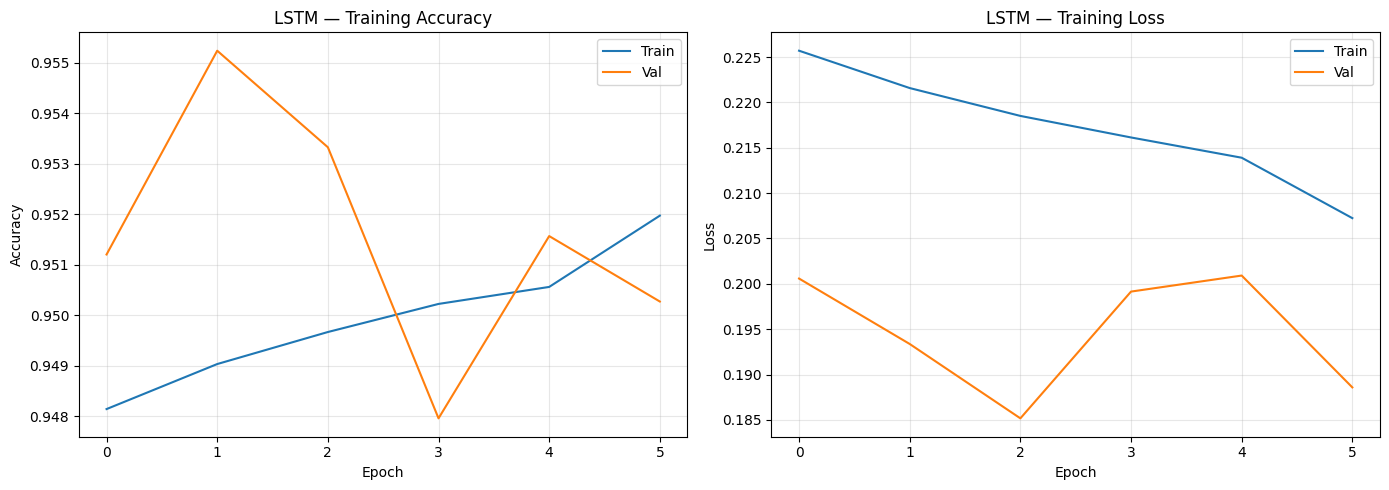

Saved: /content/drive/MyDrive/ids-project/workspace/output/lstm_training_curves.png


In [17]:
# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.set_title('LSTM — Training Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('LSTM — Training Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/lstm_training_curves.png')

In [18]:
# Evaluate on test set
test_loss, test_acc = model_lstm.evaluate(
    X_test_lstm, y_test_oh, verbose=0, batch_size=512
)
print(f'Test Accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)')
print(f'Test Loss     : {test_loss:.4f}')

y_pred_proba = model_lstm.predict(X_test_lstm, batch_size=512, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

report = classification_report(
    y_test, y_pred, target_names=TARGET_NAMES, output_dict=True
)
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=TARGET_NAMES))

pd.DataFrame(report).T.to_csv(f'{OUTPUT_DIR}/lstm_classification_report.csv')
print(f'Saved: {OUTPUT_DIR}/lstm_classification_report.csv')

Test Accuracy : 0.9530  (95.30%)
Test Loss     : 0.1852

Classification Report:
                          precision    recall  f1-score   support

                  Benign       0.96      0.99      0.97    903232
        DDOS attack-HOIC       1.00      1.00      1.00    205704
  DDoS attacks-LOIC-HTTP       1.00      0.99      1.00    172522
        DoS attacks-Hulk       1.00      1.00      1.00    138030
                     Bot       1.00      1.00      1.00     85834
          FTP-BruteForce       0.71      0.79      0.75     58032
          SSH-Bruteforce       1.00      1.00      1.00     56446
           Infilteration       0.60      0.23      0.34     49058
DoS attacks-SlowHTTPTest       0.65      0.54      0.59     41888
   DoS attacks-GoldenEye       0.99      1.00      1.00     12320
   DoS attacks-Slowloris       0.96      0.97      0.96      3314
    DDOS attack-LOIC-UDP       0.68      1.00      0.81       510
        Brute Force -Web       0.21      0.74      0.32      

In [19]:
# Per-class metrics table
metrics_rows = []
for c in range(N_CLASSES):
    name = ATTACK_NAMES[c]
    if name in report:
        r = report[name]
        metrics_rows.append({
            'Class'    : c,
            'Attack'   : name,
            'Precision': round(r['precision'], 4),
            'Recall'   : round(r['recall'],    4),
            'F1-Score' : round(r['f1-score'],  4),
            'Support'  : int(r['support']),
        })

metrics_df = pd.DataFrame(metrics_rows)
print('Per-Class Metrics (Test Set):')
print(metrics_df[['Class','Attack','Precision','Recall','F1-Score']].to_string(index=False))
print(f"\nMean F1    : {metrics_df['F1-Score'].mean():.4f}")
print(f"Macro Prec : {metrics_df['Precision'].mean():.4f}")
print(f"Macro Rec  : {metrics_df['Recall'].mean():.4f}")

metrics_df.to_csv(f'{OUTPUT_DIR}/lstm_per_class_metrics.csv', index=False)
print(f'Saved: {OUTPUT_DIR}/lstm_per_class_metrics.csv')

Per-Class Metrics (Test Set):
 Class                   Attack  Precision  Recall  F1-Score
     0                   Benign     0.9595  0.9879    0.9735
     1         DDOS attack-HOIC     0.9998  1.0000    0.9999
     2   DDoS attacks-LOIC-HTTP     0.9980  0.9941    0.9960
     3         DoS attacks-Hulk     0.9993  0.9996    0.9994
     4                      Bot     0.9974  0.9995    0.9985
     5           FTP-BruteForce     0.7054  0.7941    0.7471
     6           SSH-Bruteforce     0.9988  0.9983    0.9986
     7            Infilteration     0.6047  0.2334    0.3368
     8 DoS attacks-SlowHTTPTest     0.6535  0.5407    0.5918
     9    DoS attacks-GoldenEye     0.9921  0.9997    0.9959
    10    DoS attacks-Slowloris     0.9576  0.9680    0.9628
    11     DDOS attack-LOIC-UDP     0.6818  1.0000    0.8108
    12         Brute Force -Web     0.2052  0.7396    0.3213
    13         Brute Force -XSS     0.0452  0.8140    0.0857
    14            SQL Injection     0.0128  0.6923    0

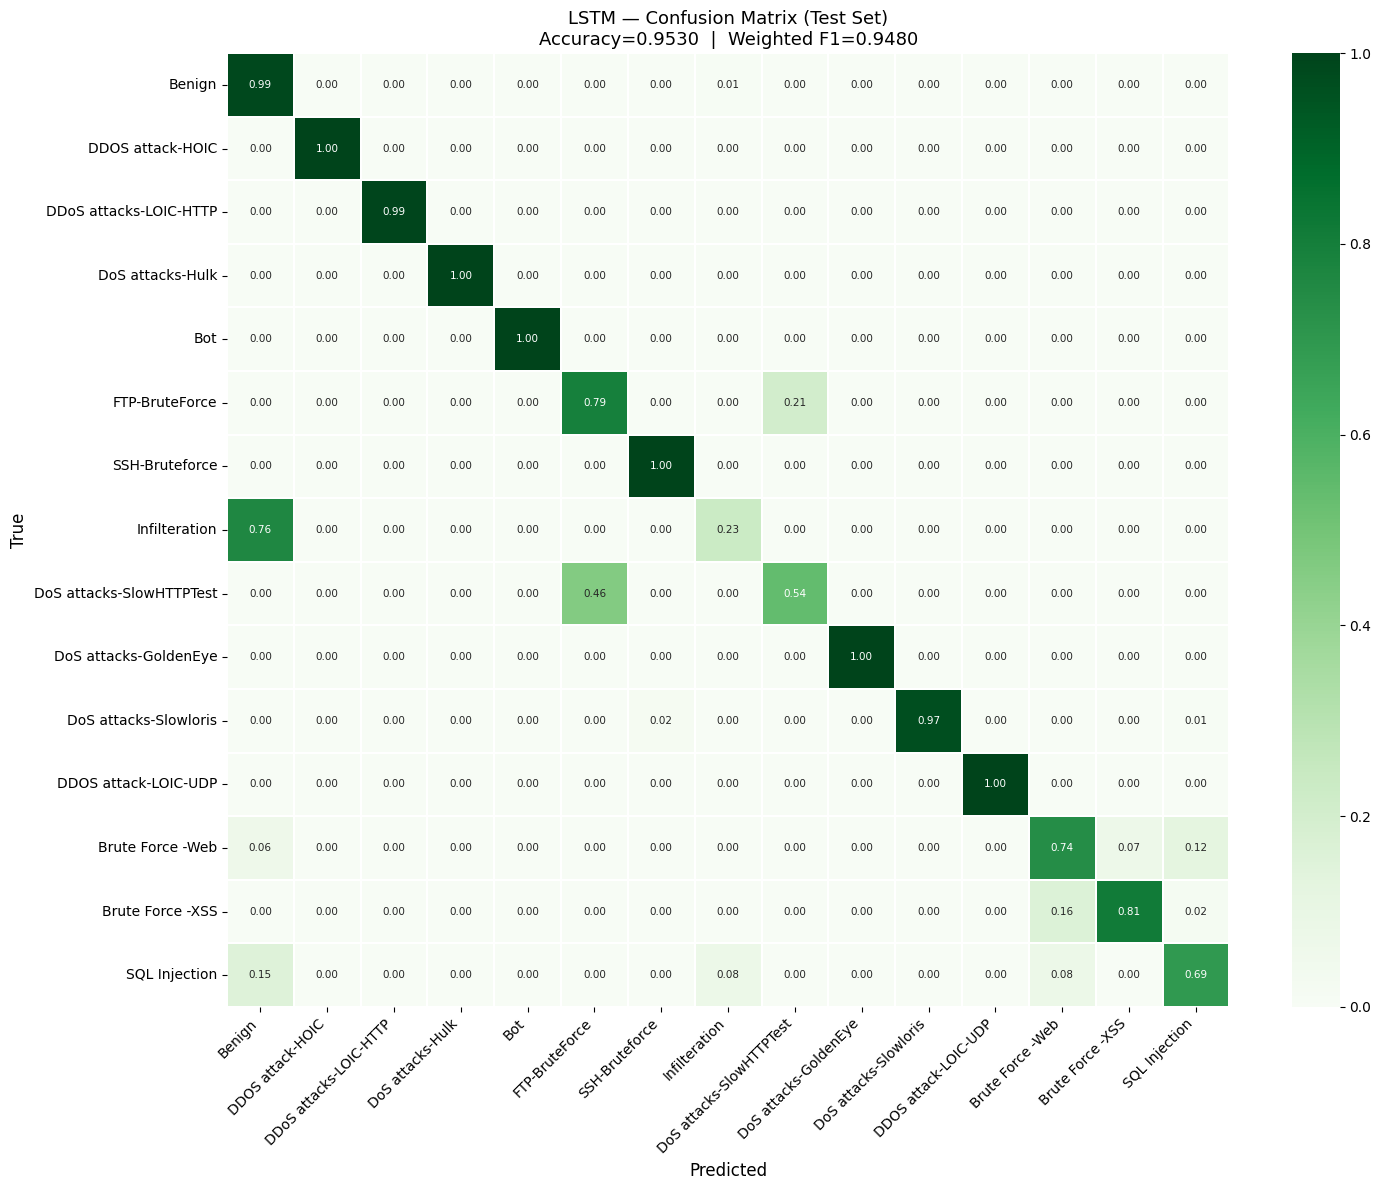

Saved: /content/drive/MyDrive/ids-project/workspace/output/lstm_confusion_matrix.png


In [20]:
# Confusion matrix
n_cls = len(ATTACK_NAMES)
cm    = confusion_matrix(y_test, y_pred)

row_sums = cm.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
cm_norm = cm / row_sums

labels = [ATTACK_NAMES[i] for i in range(n_cls)]

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f',
    xticklabels=labels, yticklabels=labels,
    cmap='Greens', linewidths=0.3, ax=ax,
    annot_kws={'size': 7.5}, vmin=0, vmax=1,
)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title(
    f'LSTM — Confusion Matrix (Test Set)\n'
    f'Accuracy={test_acc:.4f}  |  Weighted F1={report["weighted avg"]["f1-score"]:.4f}',
    fontsize=13
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lstm_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUTPUT_DIR}/lstm_confusion_matrix.png')

In [23]:
# Summary and save
print('=' * 60)
print('  LSTM — FINAL SUMMARY')
print('=' * 60)
print(f'  Features        : {len(FEATURE_COLS)} (timestamp_unix excluded)')
print(f'  Architecture    : LSTM(200, return_seq) -> Dropout(0.5) -> LSTM(200) -> Dropout(0.5) -> Softmax')
print(f'  Class weights   : inv-freq, Benign floor=0.4, cap={MAX_WEIGHT}')
print(f'  Batch size      : {BATCH_SIZE}')
print(f'  Epochs trained  : 12 / {EPOCHS}')
print()
print(f'  {"Metric":22s}  {"Value":>8}')
print(f'  {"-"*34}')
print(f'  {"Accuracy":22s}  {test_acc:.4f}')
print(f'  {"Weighted F1":22s}  {report["weighted avg"]["f1-score"]:.4f}')
print(f'  {"Weighted Precision":22s}  {report["weighted avg"]["precision"]:.4f}')
print(f'  {"Weighted Recall":22s}  {report["weighted avg"]["recall"]:.4f}')
print(f'  {"Macro F1":22s}  {report["macro avg"]["f1-score"]:.4f}')

model_lstm.save(f'{MODEL_DIR}/lstm_final.keras')
print(f'\nModel saved: {MODEL_DIR}/lstm_final.keras')

metadata = {
    'model'             : 'LSTM',
    'n_features'        : N_FEATURES,
    'feature_cols'      : FEATURE_COLS,
    'n_classes'         : N_CLASSES,
    'attack_names'      : ATTACK_NAMES,
    'architecture'      : 'LSTM(200, return_seq) -> Dropout(0.5) -> LSTM(200) -> Dropout(0.5) -> Softmax',
    'batch_size'        : BATCH_SIZE,
    'epochs_trained'    : len(history.history['loss']),
    'max_epochs'        : EPOCHS,
    'learning_rate'     : 0.0001,
    'class_weights_used': True,
    'max_weight'        : MAX_WEIGHT,
    'test_accuracy'     : round(float(test_acc), 4),
    'test_loss'         : round(float(test_loss), 4),
    'weighted_f1'       : round(report['weighted avg']['f1-score'], 4),
    'macro_f1'          : round(report['macro avg']['f1-score'], 4),
    'per_class_metrics' : metrics_df.set_index('Class')[['Precision','Recall','F1-Score']].round(4).to_dict(),
    'timestamp'         : time.strftime('%Y-%m-%d %H:%M:%S'),
}
with open(f'{OUTPUT_DIR}/lstm_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print(f'Metadata saved: {OUTPUT_DIR}/lstm_metadata.json')

  LSTM — FINAL SUMMARY
  Features        : 29 (timestamp_unix excluded)
  Architecture    : LSTM(200, return_seq) -> Dropout(0.5) -> LSTM(200) -> Dropout(0.5) -> Softmax
  Class weights   : inv-freq, Benign floor=0.4, cap=15.0
  Batch size      : 256
  Epochs trained  : 12 / 50

  Metric                     Value
  ----------------------------------
  Accuracy                0.9530
  Weighted F1             0.9480
  Weighted Precision      0.9484
  Weighted Recall         0.9530
  Macro F1                0.7229

Model saved: /content/drive/MyDrive/ids-project/workspace/models/lstm_final.keras
Metadata saved: /content/drive/MyDrive/ids-project/workspace/output/lstm_metadata.json
